In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')
# from plotly import express as px
# from scipy import signal as sn
# from scipy.constants import Rydberg as R
from scipy import optimize as o
plt.rcParams.update({
    "figure.figsize": (12, 9),
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 15})

In [ ]:
LU_cubo = pd.read_csv('datos/times_LU_cubo.csv')
GS_cubo = pd.read_csv('datos/times_GS_cubo.csv')
pcg_cubo = pd.read_csv('datos/times_pcg_cubo.csv')

n_LU = LU_cubo['N']
t_LU = LU_cubo['t']
n_GS = GS_cubo['N']
t_GS = GS_cubo['t']
n_pcg = pcg_cubo['N']
t_pcg = pcg_cubo['t']

x_LU = LU_cubo['norm_x']
n_len = len(x_LU)

x_GS = GS_cubo['norm_x'][:n_len]
x_pcg = pcg_cubo['norm_x'][:n_len]




In [50]:
print(np.linalg.norm(x_LU-x_pcg))
print(np.linalg.norm(x_pcg-x_GS))
print(np.sum((n_pcg-n_GS[:n_len])**2))
print(np.sum((n_LU-n_pcg[:n_len])**2))



2.4089857011671155e-15
3.8892341379072623e-07
0.0
0


In [54]:
cut = 1
p_LU = np.polyfit(np.log(n_LU[cut:]),np.log(t_LU[cut:]),1); print(p_LU, 'LU')
p_GS = np.polyfit(np.log(n_GS[cut:]),np.log(t_GS[cut:]),1); print(p_GS, 'GS')
p_pcg = np.polyfit(np.log(n_pcg[-8:]),np.log(t_pcg[-8:]),1); print(p_pcg, 'pcg')

z_LU = np.poly1d(p_LU)
z_GS = np.poly1d(p_GS)
z_pcg = np.poly1d(p_pcg)



[  2.6332147  -12.13532953] LU
[  2.22358569 -10.01574969] GS
[  1.34015974 -16.19666556] pcg


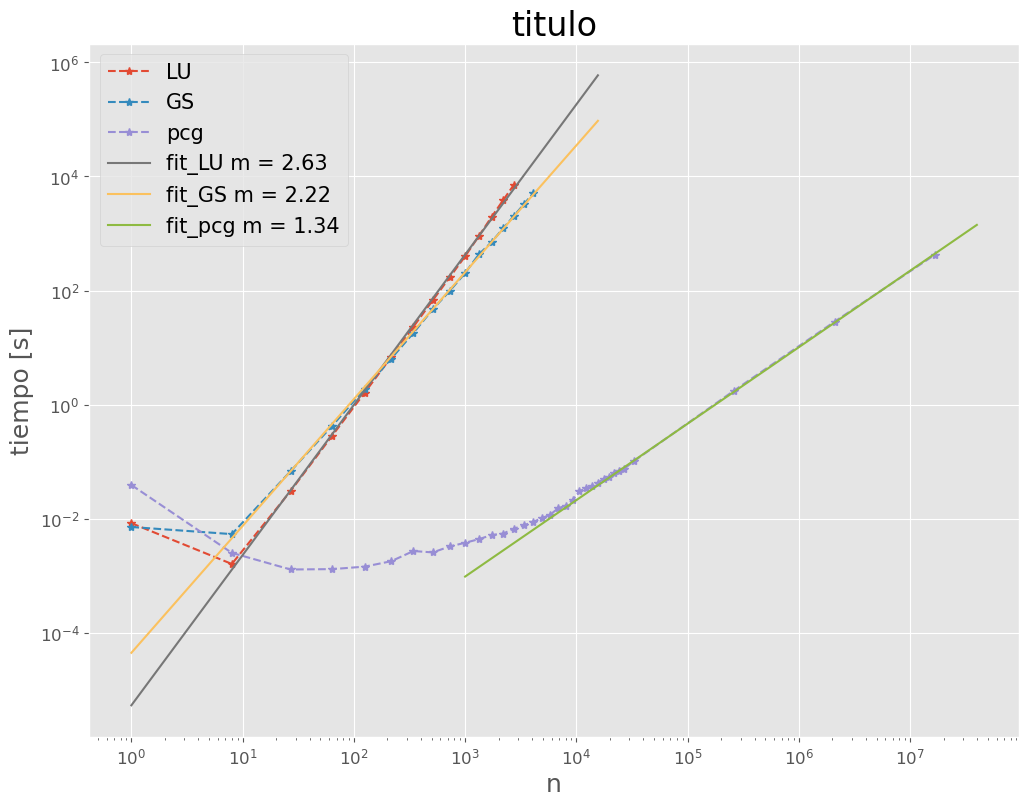

In [30]:
k = np.logspace(3,7.6,50,base=10)
plt.loglog(n_LU,t_LU,'--*',label='LU')

plt.loglog(n_GS,t_GS,'--*',label='GS')

plt.loglog(n_pcg,t_pcg,'--*',label='pcg')
plt.plot(n_pcg[:-9],np.exp(z_LU(np.log(n_pcg[:-9]))),label='fit_LU m = 2.63')
plt.plot(n_pcg[:-9],np.exp(z_GS(np.log(n_pcg[:-9]))),label='fit_GS m = 2.22')
plt.plot(k,np.exp(z_pcg(np.log(k))),label='fit_pcg m = 1.34')

plt.title('titulo')
plt.xlabel('n')
plt.ylabel('tiempo [s]')
plt.legend()

